In [34]:
import pathlib
import numpy as np
import scipy as sp
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
import pingouin as pg
import seaborn as sns


import STX3KO_analyses as stx
from STX3KO_analyses import utilities as u

ko_mice = stx.ymaze_sess_deets.ko_mice
ctrl_mice = stx.ymaze_sess_deets.ctrl_mice
sparse_mice = stx.ymaze_sess_deets.sparse_mice

plt.rcParams['pdf.fonttype']=42

%matplotlib inline

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [27]:
sess = u.load_single_day(sparse_mice[1], 0)

{'date': '26_05_2025', 'scene': 'YMaze_LNovel', 'session': 4, 'scan': 7, 'novel_arm': 1, 'exp_day': 1}


In [41]:
# fig, ax = plt.subplots(1,1)
rows = []
for mouse in sparse_mice:
    for day in range(6):
        if (mouse == 'SparseKO_09') and (day==2):
            continue 
        sess = u.load_single_day(mouse,day)
        
        for chan in ('channel_0', 'channel_1'):
            skew_ch0 = sp.stats.skew(sess.timeseries[f'{chan}_F_dff'], axis=1, nan_policy='omit')
            for cell_skew in skew_ch0:
                rows.append({'mouse': mouse,
                            'day': day,
                            'chan': chan,
                            'skew': cell_skew})

       
df = pd.DataFrame(rows)




  
    # bins = np.arange(30)
    # ax.hist(skew_ch0, bins=bins, alpha=0.5, label='STX3(-) cells', color='red', 
    #     density=True, cumulative=True, fill=False)
    # ax.hist(skew_ch1, bins=bins, alpha=0.5, label='STX3(+) cells', color='black', 
    #     density=True, cumulative=True, fill=False)
    # # ax.scatter(skew_ch0, skew_ch1)
    # ax.set_xlabel('Skew STX3(-) cells')
    # ax.set_ylabel('Skew STX3(+) cells')

{'date': '16_11_2024', 'scene': 'YMaze_LNovel', 'session': 4, 'scan': 14, 'novel_arm': -1, 'exp_day': 1}
{'date': '17_11_2024', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 25, 'novel_arm': -1, 'exp_day': 2}
{'date': '18_11_2024', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 18, 'novel_arm': -1, 'exp_day': 3}
{'date': '19_11_2024', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': -1, 'exp_day': 4}
{'date': '20_11_2024', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 12, 'novel_arm': -1, 'exp_day': 5}
{'date': '21_11_2024', 'scene': 'YMaze_LNovel', 'session': 2, 'scan': 8, 'novel_arm': -1, 'exp_day': 6}
{'date': '26_05_2025', 'scene': 'YMaze_LNovel', 'session': 4, 'scan': 7, 'novel_arm': 1, 'exp_day': 1}
{'date': '27_05_2025', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 23, 'novel_arm': 1, 'exp_day': 2}
{'date': '28_05_2025', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 25, 'novel_arm': 1, 'exp_day': 3}
{'date': '29_05_2025', 'scene': 'YMaze_LNovel', 'session': 1,

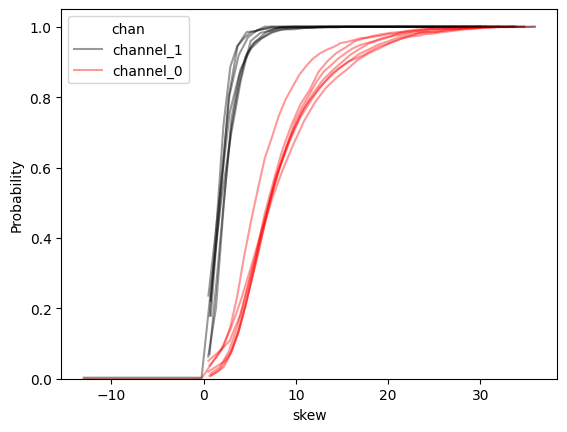

In [ ]:
fig, ax = plt.subplots()
bins = np.linspace(0,35)
for mouse in sparse_mice:
    sns.histplot(data = df.loc[df['mouse']==mouse], 
                x = 'skew', 
                hue = 'chan', 
                hue_order = ['channel_1', 'channel_0'],
                palette = ['black', 'red'],
                stat = 'probability',
                cumulative = True,
                fill=False,
                element='poly',
                common_norm = False, 
                alpha=.4,
                bins=bins,
                ax=ax)

In [57]:
rows = []
for cond, mice in zip(('ctrl', 'ko'), (ctrl_mice, ko_mice)):
    for mouse in mice:
        for day in range(6):
            
            sess = u.load_single_day(mouse,day)
            
            # for chan in ('channel_0', 'channel_1'):
            skew = sp.stats.skew(sess.timeseries['F_dff'], axis=1, nan_policy='omit')
            print(skew.shape)
            for cell in skew:
                rows.append({'mouse': mouse,
                            'day': day,
                            'cond': cond,
                            'skew': cell})

df = pd.DataFrame(rows)

{'date': '29_11_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'ravel_ind': 0}
(1381,)
{'date': '30_11_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 7, 'novel_arm': -1, 'ravel_ind': 1}
(1093,)
{'date': '01_12_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': -1, 'ravel_ind': 2}
(972,)
{'date': '02_12_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'ravel_ind': 3}
(1068,)
{'date': '03_12_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 8, 'novel_arm': -1, 'ravel_ind': 4}
(962,)
{'date': '04_12_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 2, 'novel_arm': -1, 'ravel_ind': 5}
(1370,)
{'date': '29_11_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': 1, 'ravel_ind': 0}
(1283,)
{'date': '30_11_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': 1, 'ravel_ind': 1}
(1170,)
{'date': '01_12_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': 1, 'ra

/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")


(1428,)
{'date': '14_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': 1, 'ravel_ind': 0}
(1030,)
{'date': '15_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': 1, 'ravel_ind': 1}
(799,)
{'date': '16_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 2, 'novel_arm': 1, 'ravel_ind': 2}
(961,)
{'date': '17_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 2, 'novel_arm': 1, 'ravel_ind': 3}
(985,)
{'date': '18_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 1, 'novel_arm': 1, 'ravel_ind': 4}
(965,)
{'date': '19_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 5, 'novel_arm': 1, 'ravel_ind': 5}
(1079,)
{'date': '14_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 2, 'novel_arm': -1, 'ravel_ind': 0}
(909,)
{'date': '15_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 2, 'novel_arm': -1, 'ravel_ind': 1}
(873,)
{'date': '16_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'r

/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")


(904,)
{'date': '29_09_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'ravel_ind': 2}


...

(1233,)
{'date': '02_10_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'ravel_ind': 4}


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")


(1087,)
{'date': '03_10_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 6, 'novel_arm': -1, 'ravel_ind': 5}


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")


(1115,)
{'date': '28_09_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 5, 'novel_arm': 1, 'ravel_ind': 0}
(1148,)
{'date': '29_09_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': 1, 'ravel_ind': 1}
(1505,)
{'date': '30_09_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': 1, 'ravel_ind': 2}
(1346,)
{'date': '01_10_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 2, 'novel_arm': 1, 'ravel_ind': 3}
(1389,)
{'date': '02_10_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': 1, 'ravel_ind': 4}
(1154,)
{'date': '03_10_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': 1, 'ravel_ind': 5}
(1223,)
{'date': '28_09_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': -1, 'ravel_ind': 0}
(1578,)
{'date': '29_09_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'ravel_ind': 1}
(1554,)
{'date': '30_09_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 5, 'novel_arm': 

In [58]:
df.head()

,mouse,day,cond,skew
0,4467331.1,0,ctrl,3.374950
1,4467331.1,0,ctrl,4.515246
2,4467331.1,0,ctrl,2.509877
3,4467331.1,0,ctrl,2.414171
4,4467331.1,0,ctrl,3.060457


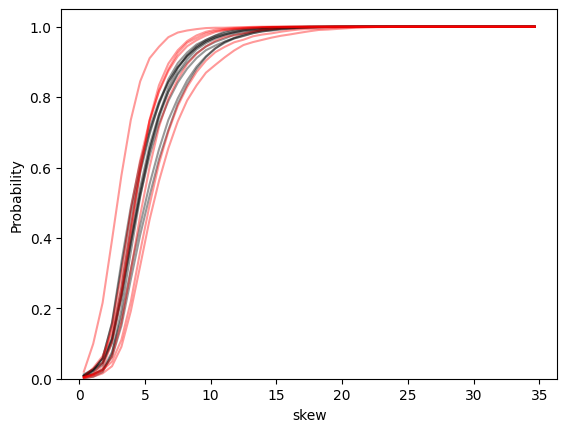

In [59]:
fig, ax = plt.subplots()
bins = np.linspace(0,35)
for cond, mice, color in zip(('ctrl', 'ko'), (ctrl_mice, ko_mice), ('black', 'red')):
    for mouse in mice:
        sns.histplot(data = df.loc[df['mouse']==mouse], 
                    x = 'skew', 
                    # hue = 'chan', 
                    # hue_order = ['channel_1', 'channel_0'],
                    # palette = ['black', 'red'],
                    color=color,
                    stat = 'probability',
                    cumulative = True,
                    fill=False,
                    element='poly',
                    common_norm = False, 
                    alpha=.4,
                    bins=bins,
                    ax=ax)

In [ ]:
df_mu = 

In [ ]:
# plot example dff from each channel from a sparse mouse

# plot distribution of dff values with skewness annotated for two examples


# 

In [ ]:
# plot example dff from an example cell from ctrl and cre mice